In [1]:
import pandas as pd
df = pd.read_parquet("../data/raw/yellow_tripdata_2026-01.parquet")
print(df.shape)
print(df.columns.tolist())

(3724889, 20)
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']


In [2]:
print(df['tpep_pickup_datetime'].dtype)
print(df['tpep_pickup_datetime'].min(), df['tpep_pickup_datetime'].max())

datetime64[us]
2025-12-31 23:57:29 2026-02-01 00:45:01


In [3]:
mask = (df['tpep_pickup_datetime'] >= '2026-01-01') & (df['tpep_pickup_datetime'] < '2026-02-01')
df_jan = df[mask]

print(df.shape, '->', df_jan.shape)
print(df_jan['tpep_pickup_datetime'].min(), "   ", df_jan['tpep_pickup_datetime'].max())

(3724889, 20) -> (3724882, 20)
2026-01-01 00:00:00     2026-01-31 23:59:59


In [4]:
hourly = df_jan.set_index('tpep_pickup_datetime').resample('h').size()
print(hourly.shape)
hourly.head(24)

(744,)


tpep_pickup_datetime
2026-01-01 00:00:00     9294
2026-01-01 01:00:00    10254
2026-01-01 02:00:00     7853
2026-01-01 03:00:00     6529
2026-01-01 04:00:00     4108
2026-01-01 05:00:00     2224
2026-01-01 06:00:00     2092
2026-01-01 07:00:00     1930
2026-01-01 08:00:00     1719
2026-01-01 09:00:00     2245
2026-01-01 10:00:00     3172
2026-01-01 11:00:00     4294
2026-01-01 12:00:00     5271
2026-01-01 13:00:00     5390
2026-01-01 14:00:00     5641
2026-01-01 15:00:00     6255
2026-01-01 16:00:00     5838
2026-01-01 17:00:00     5738
2026-01-01 18:00:00     5466
2026-01-01 19:00:00     4773
2026-01-01 20:00:00     4280
2026-01-01 21:00:00     4057
2026-01-01 22:00:00     3373
2026-01-01 23:00:00     2670
Freq: h, dtype: int64

### Findings
- 3.72M trip-level rows. Target BUILT via resample('h').size() → ~744 hrs.
- Trimmed 7 spillover rows (Dec/Feb) before aggregating.
- Jan 1 abnormal: NYE tail (high 00-01h) + holiday dip (low 08h). Anomaly candidate.

<Axes: xlabel='tpep_pickup_datetime'>

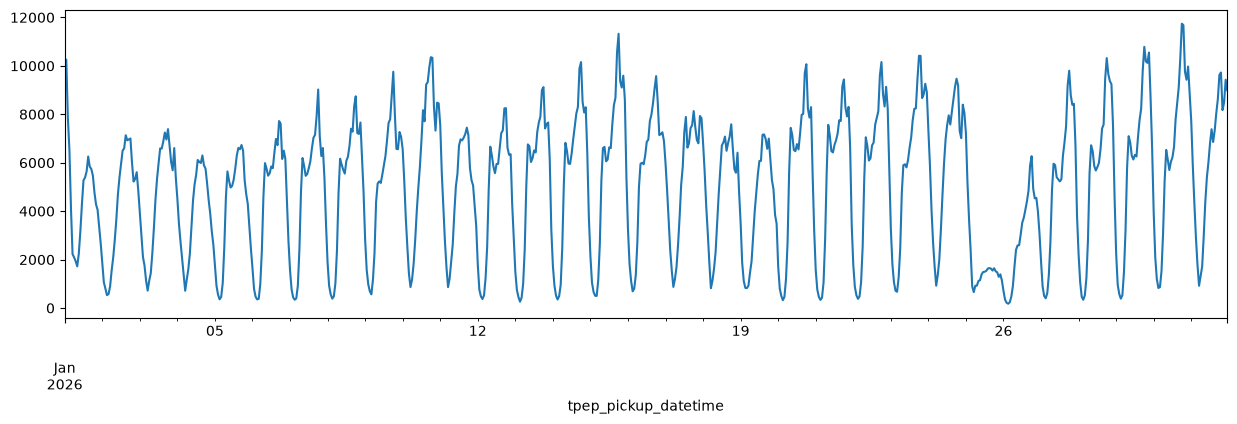

In [5]:
hourly.plot(figsize=(15, 4))

### EDA findings (raw hourly plot)
- Daily seasonality: sharp 24h cycle (afternoon peak, ~5-6am trough).
- Weekly seasonality: peak heights vary by day-of-week (weekend higher).
- Anomaly ~Jan 26: deep multi-day dip (likely snowstorm — verify). Anomaly-detection example.
- Series is seasonal → NON-stationary (mean shifts with hour/day).